# Actor-Critic Methods
## Advantage Actor-Critic (A2C) and Generalized Advantage Estimation (GAE)

This notebook provides a self-contained, from-scratch implementation of **Actor-Critic** methods for reinforcement learning. We build an Advantage Actor-Critic (A2C) agent with Generalized Advantage Estimation (GAE), train it on classic control tasks, and study the interplay between policy learning, value estimation, and exploration.

**What you'll learn:**
1. Actor-critic architecture: why combine policy and value learning
2. Advantage function and its role in variance reduction
3. A2C: synchronous advantage actor-critic
4. GAE(λ): Generalized Advantage Estimation for bias-variance control
5. Entropy regularization for exploration
6. Application to CartPole and LunarLander

**Prerequisites:** Policy gradients (Notebook 7), TD learning (Notebook 3).

**References:**
- Sutton & Barto, *Reinforcement Learning: An Introduction*, 2nd Ed., MIT Press, 2018, Chapter 13.
- Mnih et al., *Asynchronous Methods for Deep Reinforcement Learning*, ICML, 2016 (A3C).
- Schulman et al., *High-Dimensional Continuous Control Using Generalized Advantage Estimation*, ICLR, 2016 (GAE).

---
## 1. Imports and Configuration

In [1]:
# ============================================================
#  Imports and Configuration
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# ---- Reproducibility ----
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ---- Hyperparameters ----
GAMMA = 0.99          # Discount factor
LR_ACTOR = 3e-4       # Actor learning rate
LR_CRITIC = 1e-3      # Critic learning rate
ENTROPY_COEF = 0.01   # Entropy bonus coefficient c_2
VALUE_COEF = 0.5      # Value loss coefficient c_1
GAE_LAMBDA = 0.95     # GAE lambda
N_EPISODES = 1000     # Training episodes
HIDDEN_DIM = 128      # Hidden layer size

# ---- Plot style ----
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})
COLORS = ['steelblue', 'coral', 'seagreen', 'goldenrod', 'mediumpurple']

# ---- Device ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")

Device: cpu
PyTorch version: 2.10.0
Gymnasium version: 1.2.3


---
## 2. Actor-Critic Framework

The actor-critic architecture combines two components:

- **Actor** $\pi_\theta(a|s)$: a parameterised policy that selects actions.
- **Critic** $V_\phi(s)$: a value function that evaluates states.

The actor uses the critic's estimate to compute lower-variance policy gradient updates,
instead of relying on full Monte-Carlo returns (as in REINFORCE).

```
         State s
        /       \
       v         v
   [Actor]    [Critic]
      |           |
   action a    value V(s)
      |           |
      +-----+-----+
            |
     Advantage A(s,a)
            |
     Policy Gradient
```

**Why actor-critic?**  Pure policy gradient methods (REINFORCE) suffer from high variance
because they use the full episode return $G_t$ as the gradient weight. Actor-critic
methods replace $G_t$ with a lower-variance advantage estimate based on the learned
value function, leading to faster and more stable learning.

---
## 3. Advantage Function

The **advantage function** measures how much better an action is compared to the
average action under the current policy:

$$A^\pi(s, a) = Q^\pi(s, a) - V^\pi(s)$$

Since we estimate $V^\pi(s)$ with our critic, we can form a one-step **TD advantage**:

$$\boxed{\hat{A}_t = r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t) = \delta_t}$$

where $\delta_t$ is the **TD error**. This single-step estimate has low variance
but may introduce bias (since $V_\phi$ is approximate). We will later see how GAE
provides a smooth interpolation between low-bias and low-variance estimates.

---
## 4. A2C: Advantage Actor-Critic

The **A2C** (synchronous Advantage Actor-Critic) algorithm updates the actor and critic
using the following losses:

- **Actor loss** (policy gradient with advantage): $L_{\text{actor}} = -\log \pi_\theta(a_t|s_t) \hat{A}_t$
- **Critic loss** (value regression): $L_{\text{critic}} = (G_t - V_\phi(s_t))^2$
- **Entropy bonus** (exploration): $\mathcal{H}[\pi_\theta(\cdot|s)] = -\sum_a \pi_\theta(a|s) \log \pi_\theta(a|s)$

The combined loss is:

$$\boxed{L = -\mathbb{E}\left[\log \pi_\theta(a_t|s_t) \hat{A}_t\right] + c_1 \mathbb{E}\left[(V_\phi(s_t) - G_t)^2\right] - c_2 \mathcal{H}[\pi_\theta]}$$

where $c_1$ controls the critic loss weight and $c_2$ controls the entropy regularisation
strength. The entropy term prevents premature convergence to a deterministic policy.

---
## 5. GAE(λ): Generalized Advantage Estimation

**Generalized Advantage Estimation** (Schulman et al., 2016) provides a family of
advantage estimators parameterised by $\lambda \in [0, 1]$:

$$\boxed{\hat{A}_t^{\text{GAE}(\gamma,\lambda)} = \sum_{l=0}^{\infty} (\gamma\lambda)^l \delta_{t+l}}$$

where $\delta_t = r_t + \gamma V(s_{t+1}) - V(s_t)$ is the TD error.

**Special cases:**
- $\lambda = 0$: $\hat{A}_t = \delta_t$ (one-step TD advantage, low variance, higher bias)
- $\lambda = 1$: $\hat{A}_t = \sum_{l=0}^{\infty} \gamma^l \delta_{t+l} = G_t - V(s_t)$ (Monte Carlo advantage, high variance, no bias)

In practice, $\lambda \in [0.9, 0.99]$ gives a good balance. The computation is done
efficiently via a backward pass:

$$\hat{A}_t = \delta_t + \gamma \lambda \hat{A}_{t+1}$$

---
## 6. Network Architectures

In [2]:
# ============================================================
#  Shared Actor-Critic Network
# ============================================================

class ActorCriticNetwork(nn.Module):
    """Actor-Critic with shared feature extraction layers.
    
    Architecture:
        state -> shared_fc1 -> ReLU -> shared_fc2 -> ReLU
              -> actor_head  -> softmax (action probabilities)
              -> critic_head -> scalar  (state value)
    """
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = HIDDEN_DIM):
        super().__init__()
        # Shared feature extraction layers
        self.shared = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        # Actor head: outputs action probabilities
        self.actor_head = nn.Linear(hidden_dim, action_dim)
        # Critic head: outputs scalar state value
        self.critic_head = nn.Linear(hidden_dim, 1)
        
    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """Forward pass.
        
        Returns:
            action_probs: probability distribution over actions
            state_value:  estimated V(s)
        """
        features = self.shared(state)
        action_probs = F.softmax(self.actor_head(features), dim=-1)
        state_value = self.critic_head(features)
        return action_probs, state_value


class SeparateActorCritic(nn.Module):
    """Actor and Critic with separate networks (no shared layers).
    
    This allows independent learning dynamics for policy and value.
    """
    
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = HIDDEN_DIM):
        super().__init__()
        # Actor network
        self.actor = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
        )
        # Critic network
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        action_probs = F.softmax(self.actor(state), dim=-1)
        state_value = self.critic(state)
        return action_probs, state_value


# Quick test
test_net = ActorCriticNetwork(state_dim=4, action_dim=2)
test_state = torch.randn(1, 4)
probs, val = test_net(test_state)
print(f"Action probs: {probs.detach().numpy().round(3)}")
print(f"State value:  {val.item():.4f}")
print(f"Probs sum:    {probs.sum().item():.4f}")
print(f"Shared network params: {sum(p.numel() for p in test_net.parameters()):,}")

test_sep = SeparateActorCritic(state_dim=4, action_dim=2)
print(f"Separate network params: {sum(p.numel() for p in test_sep.parameters()):,}")

Action probs: [[0.498 0.502]]
State value:  -0.0419
Probs sum:    1.0000
Shared network params: 17,539
Separate network params: 34,691


---
## 7. A2C Agent

In [3]:
# ============================================================
#  A2C Agent
# ============================================================

class A2CAgent:
    """Advantage Actor-Critic agent with GAE support."""
    
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr_actor: float = LR_ACTOR,
        lr_critic: float = LR_CRITIC,
        gamma: float = GAMMA,
        gae_lambda: float = GAE_LAMBDA,
        entropy_coef: float = ENTROPY_COEF,
        value_coef: float = VALUE_COEF,
        hidden_dim: int = HIDDEN_DIM,
        shared: bool = True,
        seed: int = SEED,
    ):
        torch.manual_seed(seed)
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.entropy_coef = entropy_coef
        self.value_coef = value_coef
        
        # Build network
        if shared:
            self.network = ActorCriticNetwork(state_dim, action_dim, hidden_dim).to(device)
            self.optimizer = optim.Adam(self.network.parameters(), lr=lr_actor)
        else:
            self.network = SeparateActorCritic(state_dim, action_dim, hidden_dim).to(device)
            # Separate learning rates for actor and critic
            self.optimizer = optim.Adam([
                {'params': self.network.actor.parameters(), 'lr': lr_actor},
                {'params': self.network.critic.parameters(), 'lr': lr_critic},
            ])
    
    def select_action(self, state: np.ndarray) -> Tuple[int, torch.Tensor, torch.Tensor]:
        """Select action using current policy.
        
        Returns:
            action:   sampled action (int)
            log_prob: log probability of chosen action
            value:    critic's estimate of V(s)
        """
        state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
        action_probs, state_value = self.network(state_t)
        dist = Categorical(action_probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), state_value.squeeze()
    
    @staticmethod
    def compute_gae(
        rewards: List[float],
        values: List[torch.Tensor],
        dones: List[bool],
        gamma: float,
        lam: float,
        next_value: float = 0.0,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """Compute Generalized Advantage Estimation.
        
        Uses the backward recursion: A_t = delta_t + gamma * lambda * A_{t+1}
        where delta_t = r_t + gamma * V(s_{t+1}) - V(s_t)
        
        Returns:
            advantages: GAE advantages (normalised)
            returns:    advantage + value (targets for critic)
        """
        T = len(rewards)
        advantages = torch.zeros(T)
        gae = 0.0
        
        # Detach values for advantage computation
        vals = [v.detach().item() for v in values]
        vals.append(next_value)  # bootstrap value for terminal
        
        # Backward pass through episode
        for t in reversed(range(T)):
            mask = 1.0 - float(dones[t])
            delta = rewards[t] + gamma * vals[t + 1] * mask - vals[t]
            gae = delta + gamma * lam * mask * gae
            advantages[t] = gae
        
        returns = advantages + torch.FloatTensor(vals[:-1])
        
        # Normalise advantages for stability
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        
        return advantages, returns
    
    def update(
        self,
        log_probs: List[torch.Tensor],
        values: List[torch.Tensor],
        rewards: List[float],
        dones: List[bool],
    ) -> Tuple[float, float, float]:
        """Update actor and critic from a collected trajectory.
        
        Returns:
            actor_loss, critic_loss, entropy (as floats)
        """
        # Compute GAE advantages and returns
        advantages, returns = self.compute_gae(
            rewards, values, dones, self.gamma, self.gae_lambda
        )
        advantages = advantages.to(device)
        returns = returns.to(device)
        
        # Stack tensors
        log_probs_t = torch.stack(log_probs)
        values_t = torch.stack(values)
        
        # Actor loss: -E[log pi(a|s) * A]
        actor_loss = -(log_probs_t * advantages.detach()).mean()
        
        # Critic loss: E[(V(s) - G)^2]
        critic_loss = F.mse_loss(values_t, returns.detach())
        
        # Entropy: -E[sum p * log p]  (computed from log_probs is approximate;
        # for exact entropy we'd need the full distribution, so we approximate)
        # We use the negative log_prob expectation as a proxy
        entropy = -log_probs_t.mean()
        
        # Combined loss
        loss = actor_loss + self.value_coef * critic_loss - self.entropy_coef * entropy
        
        # Gradient step
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.network.parameters(), max_norm=0.5)
        self.optimizer.step()
        
        return actor_loss.item(), critic_loss.item(), entropy.item()


print("A2CAgent class defined.")

A2CAgent class defined.


---
## 8. Training Loop

In [4]:
# ============================================================
#  Training Function
# ============================================================

def train_a2c(
    env_name: str,
    agent: A2CAgent,
    n_episodes: int = N_EPISODES,
    max_steps: int = 1000,
    print_every: int = 100,
    seed: int = SEED,
) -> Dict[str, List[float]]:
    """Train an A2C agent on a Gymnasium environment.
    
    Returns:
        Dictionary with episode_rewards, actor_losses, critic_losses,
        entropies, and collected advantages for analysis.
    """
    env = gym.make(env_name)
    
    history = {
        'episode_rewards': [],
        'actor_losses': [],
        'critic_losses': [],
        'entropies': [],
        'advantages_early': [],
        'advantages_mid': [],
        'advantages_late': [],
        'values': [],
        'returns_actual': [],
    }
    
    for episode in range(n_episodes):
        state, _ = env.reset(seed=seed + episode)
        
        log_probs = []
        values = []
        rewards = []
        dones = []
        
        episode_reward = 0.0
        
        # Collect full episode trajectory
        for step in range(max_steps):
            action, log_prob, value = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            log_probs.append(log_prob)
            values.append(value)
            rewards.append(reward)
            dones.append(done)
            
            episode_reward += reward
            state = next_state
            
            if done:
                break
        
        # Compute advantages for logging
        advantages, returns = agent.compute_gae(
            rewards, values, dones, agent.gamma, agent.gae_lambda
        )
        
        # Store advantages at different training stages
        if episode < n_episodes * 0.1:
            history['advantages_early'].extend(advantages.tolist())
        elif n_episodes * 0.45 < episode < n_episodes * 0.55:
            history['advantages_mid'].extend(advantages.tolist())
        elif episode > n_episodes * 0.9:
            history['advantages_late'].extend(advantages.tolist())
        
        # Store values and actual returns for scatter plot (last 50 episodes)
        if episode >= n_episodes - 50:
            vals_detached = [v.detach().item() for v in values]
            history['values'].extend(vals_detached)
            # Compute actual discounted returns
            actual_returns = []
            G = 0.0
            for r in reversed(rewards):
                G = r + agent.gamma * G
                actual_returns.insert(0, G)
            history['returns_actual'].extend(actual_returns)
        
        # Update networks
        actor_loss, critic_loss, entropy = agent.update(
            log_probs, values, rewards, dones
        )
        
        history['episode_rewards'].append(episode_reward)
        history['actor_losses'].append(actor_loss)
        history['critic_losses'].append(critic_loss)
        history['entropies'].append(entropy)
        
        if (episode + 1) % print_every == 0:
            avg_reward = np.mean(history['episode_rewards'][-100:])
            print(
                f"Episode {episode+1:5d} | "
                f"Avg Reward: {avg_reward:8.2f} | "
                f"Actor Loss: {actor_loss:7.4f} | "
                f"Critic Loss: {critic_loss:7.4f} | "
                f"Entropy: {entropy:6.4f}"
            )
    
    env.close()
    return history


def smooth(data: List[float], window: int = 50) -> np.ndarray:
    """Compute running average for smooth plotting."""
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode='valid')


print("Training utilities defined.")

Training utilities defined.


---
## 9. Experiment 1 — A2C on CartPole with TD Advantage (λ=0)

In [5]:
# ============================================================
#  Experiment 1: A2C with TD advantage (GAE lambda=0)
# ============================================================

env_test = gym.make('CartPole-v1')
state_dim = env_test.observation_space.shape[0]
action_dim = env_test.action_space.n
env_test.close()
print(f"CartPole-v1: state_dim={state_dim}, action_dim={action_dim}")

# Agent with lambda=0 (pure TD advantage)
agent_td = A2CAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gae_lambda=0.0,  # TD advantage only
    seed=SEED,
)

print("\nTraining A2C with TD advantage (lambda=0) on CartPole-v1...")
history_td = train_a2c('CartPole-v1', agent_td, n_episodes=N_EPISODES)

CartPole-v1: state_dim=4, action_dim=2

Training A2C with TD advantage (lambda=0) on CartPole-v1...
Episode   100 | Avg Reward:    22.48 | Actor Loss: -0.0000 | Critic Loss:  1.8275 | Entropy: 0.6733
Episode   200 | Avg Reward:    19.02 | Actor Loss: -0.0000 | Critic Loss:  5.4160 | Entropy: 0.7050
Episode   300 | Avg Reward:    21.85 | Actor Loss:  0.0000 | Critic Loss:  5.9968 | Entropy: 0.6761
Episode   400 | Avg Reward:    20.23 | Actor Loss:  0.0000 | Critic Loss:  1.1853 | Entropy: 0.5901
Episode   500 | Avg Reward:    17.45 | Actor Loss: -0.0000 | Critic Loss:  4.7907 | Entropy: 0.6567
Episode   600 | Avg Reward:    17.29 | Actor Loss:  0.0000 | Critic Loss:  2.5523 | Entropy: 0.6935
Episode   700 | Avg Reward:    23.57 | Actor Loss: -0.0000 | Critic Loss: 11.9899 | Entropy: 0.6394
Episode   800 | Avg Reward:    24.52 | Actor Loss: -0.0000 | Critic Loss: 14.0952 | Entropy: 0.6695
Episode   900 | Avg Reward:    19.82 | Actor Loss:  0.0000 | Critic Loss:  5.5804 | Entropy: 0.5420


---
## 10. Experiment 2 — A2C on CartPole with GAE (λ=0.95)

In [6]:
# ============================================================
#  Experiment 2: A2C with GAE (lambda=0.95)
# ============================================================

agent_gae = A2CAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gae_lambda=0.95,  # GAE
    seed=SEED,
)

print("Training A2C with GAE (lambda=0.95) on CartPole-v1...")
history_gae = train_a2c('CartPole-v1', agent_gae, n_episodes=N_EPISODES)

Training A2C with GAE (lambda=0.95) on CartPole-v1...
Episode   100 | Avg Reward:    22.79 | Actor Loss:  0.0000 | Critic Loss: 68.3304 | Entropy: 0.6752
Episode   200 | Avg Reward:    20.41 | Actor Loss:  0.0000 | Critic Loss: 28.7288 | Entropy: 0.6925
Episode   300 | Avg Reward:    24.71 | Actor Loss:  0.0000 | Critic Loss: 50.1940 | Entropy: 0.6797
Episode   400 | Avg Reward:    21.18 | Actor Loss: -0.0000 | Critic Loss: 16.9980 | Entropy: 0.6711
Episode   500 | Avg Reward:    24.53 | Actor Loss:  0.0000 | Critic Loss: 34.1521 | Entropy: 0.6738
Episode   600 | Avg Reward:    25.55 | Actor Loss:  0.0000 | Critic Loss: 94.0794 | Entropy: 0.6581
Episode   700 | Avg Reward:    34.97 | Actor Loss: -0.0000 | Critic Loss: 74.9216 | Entropy: 0.6521
Episode   800 | Avg Reward:    38.72 | Actor Loss:  0.0000 | Critic Loss: 18.4072 | Entropy: 0.7319
Episode   900 | Avg Reward:    43.15 | Actor Loss: -0.0000 | Critic Loss: 55.9117 | Entropy: 0.6660
Episode  1000 | Avg Reward:    56.22 | Actor L

---
## 11. Visualization 1 — Training Reward Curves for Different GAE λ Values


Training with lambda=0.0...
Episode   200 | Avg Reward:    19.02 | Actor Loss: -0.0000 | Critic Loss:  5.4160 | Entropy: 0.7050
Episode   400 | Avg Reward:    20.23 | Actor Loss:  0.0000 | Critic Loss:  1.1853 | Entropy: 0.5901
Episode   600 | Avg Reward:    17.29 | Actor Loss:  0.0000 | Critic Loss:  2.5523 | Entropy: 0.6935

Training with lambda=0.5...
Episode   200 | Avg Reward:    20.89 | Actor Loss:  0.0000 | Critic Loss:  4.7241 | Entropy: 0.6951
Episode   400 | Avg Reward:    20.33 | Actor Loss: -0.0000 | Critic Loss:  3.0143 | Entropy: 0.6720
Episode   600 | Avg Reward:    19.92 | Actor Loss: -0.0000 | Critic Loss:  4.7841 | Entropy: 0.5714

Training with lambda=0.8...
Episode   200 | Avg Reward:    23.11 | Actor Loss: -0.0000 | Critic Loss: 11.7376 | Entropy: 0.6933
Episode   400 | Avg Reward:    22.81 | Actor Loss:  0.0000 | Critic Loss: 15.4927 | Entropy: 0.6902
Episode   600 | Avg Reward:    18.30 | Actor Loss:  0.0000 | Critic Loss: 15.5288 | Entropy: 0.6521

Training wit

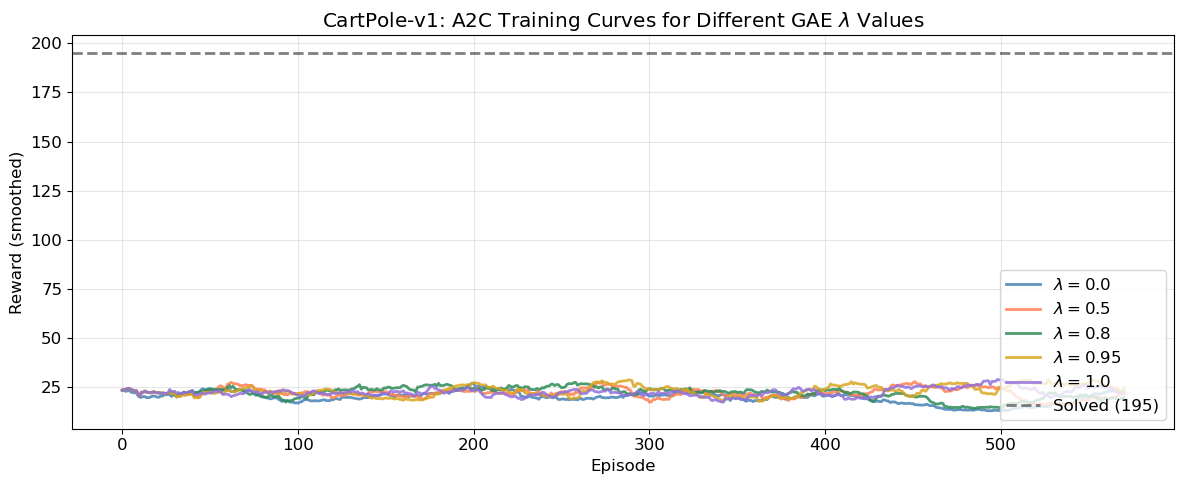

In [7]:
# ============================================================
#  Train with multiple lambda values and compare
# ============================================================

lambda_values = [0.0, 0.5, 0.8, 0.95, 1.0]
lambda_histories = {}

for i, lam in enumerate(lambda_values):
    print(f"\nTraining with lambda={lam}...")
    agent_lam = A2CAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        gae_lambda=lam,
        seed=SEED,
    )
    hist = train_a2c('CartPole-v1', agent_lam, n_episodes=600, print_every=200)
    lambda_histories[lam] = hist

# Plot reward curves
fig, ax = plt.subplots(figsize=(12, 5))
for i, (lam, hist) in enumerate(lambda_histories.items()):
    smoothed = smooth(hist['episode_rewards'], window=30)
    ax.plot(smoothed, color=COLORS[i], label=f'$\\lambda={lam}$', alpha=0.85)

ax.axhline(y=195, color='black', linestyle='--', alpha=0.5, label='Solved (195)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('CartPole-v1: A2C Training Curves for Different GAE $\\lambda$ Values')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 12. Visualization 2 — Advantage Distribution at Different Training Stages

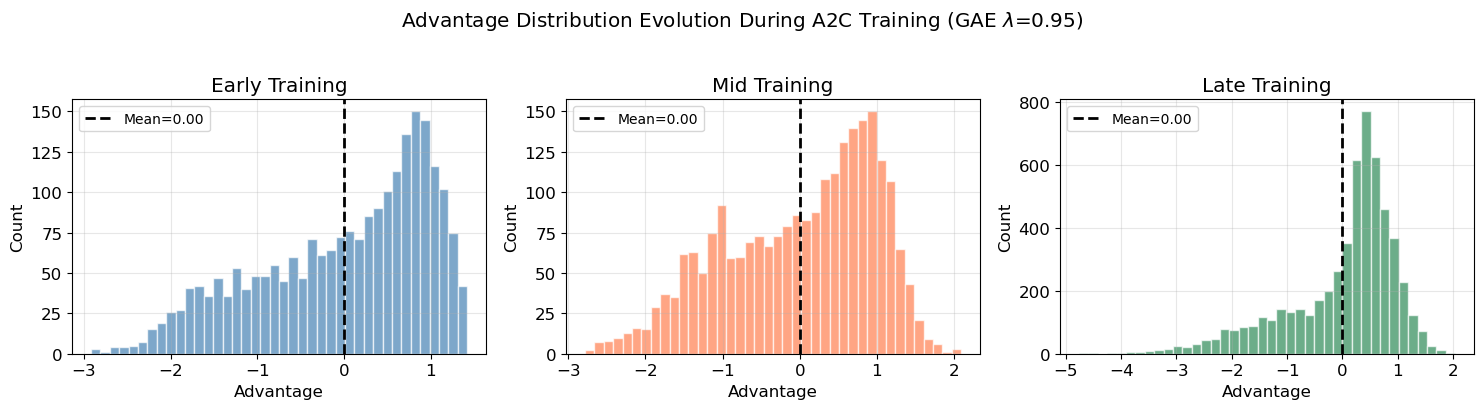

In [8]:
# ============================================================
#  Advantage distribution histograms
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stages = [
    ('advantages_early', 'Early Training', COLORS[0]),
    ('advantages_mid', 'Mid Training', COLORS[1]),
    ('advantages_late', 'Late Training', COLORS[2]),
]

for ax, (key, title, color) in zip(axes, stages):
    data = history_gae[key]
    if len(data) > 0:
        ax.hist(data, bins=40, color=color, alpha=0.7, edgecolor='white')
        ax.axvline(x=np.mean(data), color='black', linestyle='--', label=f'Mean={np.mean(data):.2f}')
        ax.set_title(title)
        ax.set_xlabel('Advantage')
        ax.set_ylabel('Count')
        ax.legend(fontsize=10)
    else:
        ax.set_title(f'{title} (no data)')

fig.suptitle('Advantage Distribution Evolution During A2C Training (GAE $\\lambda$=0.95)', y=1.02)
plt.tight_layout()
plt.show()

---
## 13. Visualization 3 — Critic Loss Over Training

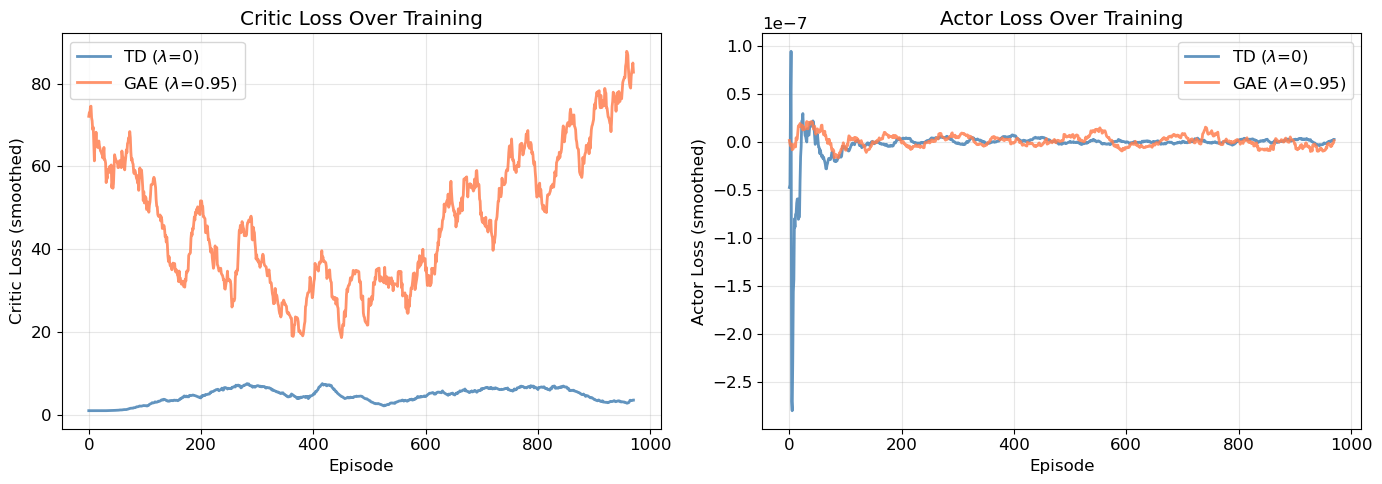

In [9]:
# ============================================================
#  Critic loss trajectory
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Critic loss: TD vs GAE
ax = axes[0]
smoothed_td = smooth(history_td['critic_losses'], window=30)
smoothed_gae_c = smooth(history_gae['critic_losses'], window=30)
ax.plot(smoothed_td, color=COLORS[0], label='TD ($\\lambda$=0)', alpha=0.85)
ax.plot(smoothed_gae_c, color=COLORS[1], label='GAE ($\\lambda$=0.95)', alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Critic Loss (smoothed)')
ax.set_title('Critic Loss Over Training')
ax.legend()

# Actor loss: TD vs GAE
ax = axes[1]
smoothed_td_a = smooth(history_td['actor_losses'], window=30)
smoothed_gae_a = smooth(history_gae['actor_losses'], window=30)
ax.plot(smoothed_td_a, color=COLORS[0], label='TD ($\\lambda$=0)', alpha=0.85)
ax.plot(smoothed_gae_a, color=COLORS[1], label='GAE ($\\lambda$=0.95)', alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Actor Loss (smoothed)')
ax.set_title('Actor Loss Over Training')
ax.legend()

plt.tight_layout()
plt.show()

---
## 14. Visualization 4 — Entropy Over Training

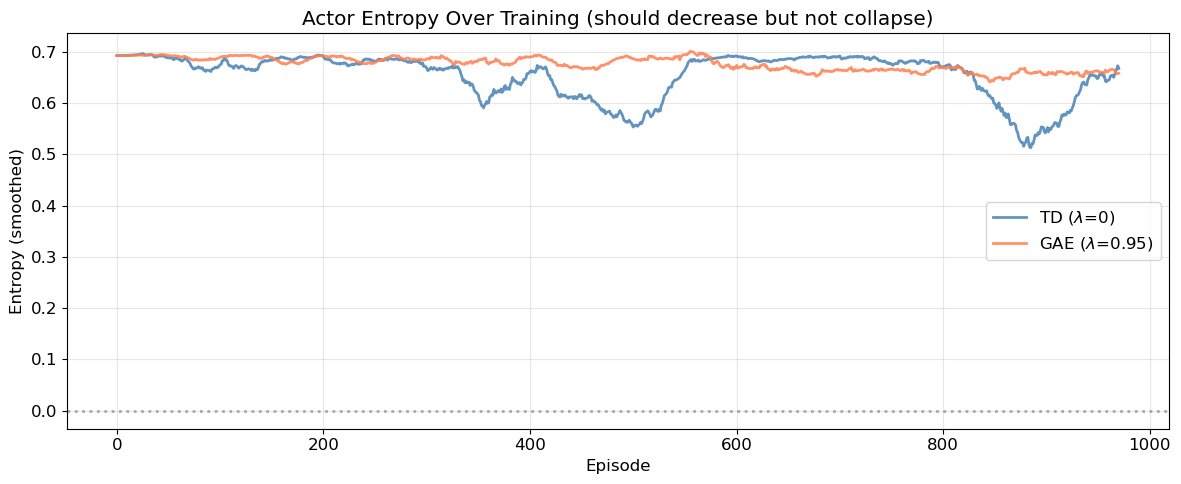

In [10]:
# ============================================================
#  Entropy trajectory: should decrease but not collapse to zero
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

smoothed_ent_td = smooth(history_td['entropies'], window=30)
smoothed_ent_gae = smooth(history_gae['entropies'], window=30)

ax.plot(smoothed_ent_td, color=COLORS[0], label='TD ($\\lambda$=0)', alpha=0.85)
ax.plot(smoothed_ent_gae, color=COLORS[1], label='GAE ($\\lambda$=0.95)', alpha=0.85)
ax.axhline(y=0, color='black', linestyle=':', alpha=0.3)
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy (smoothed)')
ax.set_title('Actor Entropy Over Training (should decrease but not collapse)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 15. Visualization 5 — Value Prediction Accuracy

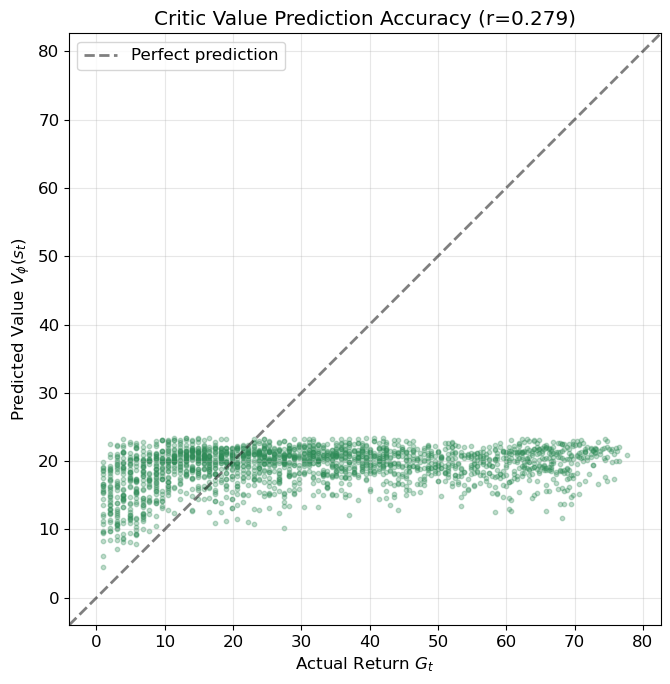

In [11]:
# ============================================================
#  V(s) vs actual returns scatter plot
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

predicted = np.array(history_gae['values'])
actual = np.array(history_gae['returns_actual'])

# Subsample if too many points
max_pts = 2000
if len(predicted) > max_pts:
    idx = np.random.choice(len(predicted), max_pts, replace=False)
    predicted = predicted[idx]
    actual = actual[idx]

ax.scatter(actual, predicted, alpha=0.3, s=10, color=COLORS[2])

# Perfect prediction line
lims = [
    min(actual.min(), predicted.min()) - 5,
    max(actual.max(), predicted.max()) + 5,
]
ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
ax.set_xlim(lims)
ax.set_ylim(lims)

# Correlation
corr = np.corrcoef(actual, predicted)[0, 1] if len(actual) > 1 else 0
ax.set_xlabel('Actual Return $G_t$')
ax.set_ylabel('Predicted Value $V_\\phi(s_t)$')
ax.set_title(f'Critic Value Prediction Accuracy (r={corr:.3f})')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 16. Experiment 3 — A2C on LunarLander with GAE

In [12]:
# ============================================================
#  Experiment 3: A2C on LunarLander-v3
# ============================================================

env_ll = gym.make('LunarLander-v3')
state_dim_ll = env_ll.observation_space.shape[0]
action_dim_ll = env_ll.action_space.n
env_ll.close()
print(f"LunarLander-v3: state_dim={state_dim_ll}, action_dim={action_dim_ll}")

agent_ll = A2CAgent(
    state_dim=state_dim_ll,
    action_dim=action_dim_ll,
    lr_actor=5e-4,
    lr_critic=1e-3,
    gae_lambda=0.95,
    entropy_coef=0.01,
    seed=SEED,
)

print("\nTraining A2C with GAE on LunarLander-v3 (this may take a few minutes)...")
history_ll = train_a2c(
    'LunarLander-v3', agent_ll,
    n_episodes=1500,
    max_steps=1000,
    print_every=200,
)

DependencyNotInstalled: Box2D is not installed, you can install it by run `pip install swig` followed by `pip install "gymnasium[box2d]"`

---
## 17. Visualization 6 — LunarLander Reward Curve

In [ ]:
# ============================================================
#  LunarLander reward curve with solved threshold
# ============================================================

fig, ax = plt.subplots(figsize=(12, 5))

raw_rewards = history_ll['episode_rewards']
smoothed_ll = smooth(raw_rewards, window=50)

ax.plot(raw_rewards, alpha=0.15, color=COLORS[3], label='Raw')
ax.plot(
    np.arange(len(smoothed_ll)) + 49,  # offset for smoothing window
    smoothed_ll, color=COLORS[3], linewidth=2.5, label='Smoothed (50)'
)
ax.axhline(y=200, color=COLORS[2], linestyle='--', alpha=0.7, label='Solved (200)')
ax.axhline(y=100, color=COLORS[1], linestyle=':', alpha=0.7, label='Threshold (100)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('LunarLander-v3: A2C with GAE($\\lambda$=0.95) Training Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 18. Experiment 4 — Shared vs Separate Networks

In [ ]:
# ============================================================
#  Shared vs Separate actor-critic networks on CartPole
# ============================================================

# Shared network
agent_shared = A2CAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gae_lambda=0.95,
    shared=True,
    seed=SEED,
)
print("Training SHARED network on CartPole-v1...")
history_shared = train_a2c('CartPole-v1', agent_shared, n_episodes=600, print_every=200)

# Separate networks
agent_separate = A2CAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    gae_lambda=0.95,
    shared=False,
    seed=SEED,
)
print("\nTraining SEPARATE networks on CartPole-v1...")
history_separate = train_a2c('CartPole-v1', agent_separate, n_episodes=600, print_every=200)

# Plot comparison
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(smooth(history_shared['episode_rewards'], 30), color=COLORS[0], label='Shared Network')
ax.plot(smooth(history_separate['episode_rewards'], 30), color=COLORS[1], label='Separate Networks')
ax.axhline(y=195, color='black', linestyle='--', alpha=0.5, label='Solved (195)')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward (smoothed)')
ax.set_title('CartPole-v1: Shared vs Separate Actor-Critic Networks')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## 19. Detailed GAE Computation Demo

In [ ]:
# ============================================================
#  Step-by-step GAE computation on a toy trajectory
# ============================================================

print("=" * 60)
print("  GAE Computation Demo on a Toy Trajectory")
print("=" * 60)

# Toy trajectory: 5 steps
demo_rewards = [1.0, 1.0, 1.0, 1.0, 0.0]
demo_values  = [torch.tensor(4.0), torch.tensor(3.5),
                torch.tensor(2.8), torch.tensor(1.5), torch.tensor(0.5)]
demo_dones   = [False, False, False, False, True]

print(f"\nRewards:  {demo_rewards}")
print(f"Values:   {[v.item() for v in demo_values]}")
print(f"Dones:    {demo_dones}")

gamma = 0.99
for lam in [0.0, 0.5, 0.95, 1.0]:
    adv, ret = A2CAgent.compute_gae(demo_rewards, demo_values, demo_dones, gamma, lam)
    print(f"\nGAE(lambda={lam}):")
    print(f"  Advantages (normalised): {adv.numpy().round(3)}")
    print(f"  Returns:                 {ret.numpy().round(3)}")

---
## 20. Entropy Analysis

In [ ]:
# ============================================================
#  Detailed entropy analysis: policy becoming more deterministic
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy over training for GAE agent (CartPole)
ax = axes[0]
ent_gae = smooth(history_gae['entropies'], window=30)
ax.plot(ent_gae, color=COLORS[4], alpha=0.85)
ax.fill_between(range(len(ent_gae)), ent_gae, alpha=0.15, color=COLORS[4])
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy')
ax.set_title('CartPole: Policy Entropy (GAE $\\lambda$=0.95)')

# Entropy over training for LunarLander
ax = axes[1]
ent_ll = smooth(history_ll['entropies'], window=50)
ax.plot(ent_ll, color=COLORS[3], alpha=0.85)
ax.fill_between(range(len(ent_ll)), ent_ll, alpha=0.15, color=COLORS[3])
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy')
ax.set_title('LunarLander: Policy Entropy (GAE $\\lambda$=0.95)')

plt.tight_layout()
plt.show()

---
## 21. Combined Loss Landscape Analysis

In [ ]:
# ============================================================
#  Combined training diagnostics: all 4 metrics in one figure
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Reward curve
ax = axes[0, 0]
ax.plot(smooth(history_gae['episode_rewards'], 30), color=COLORS[0])
ax.axhline(y=195, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('(a) Episode Reward')

# (b) Actor loss
ax = axes[0, 1]
ax.plot(smooth(history_gae['actor_losses'], 30), color=COLORS[1])
ax.set_xlabel('Episode')
ax.set_ylabel('Actor Loss')
ax.set_title('(b) Actor Loss')

# (c) Critic loss
ax = axes[1, 0]
ax.plot(smooth(history_gae['critic_losses'], 30), color=COLORS[2])
ax.set_xlabel('Episode')
ax.set_ylabel('Critic Loss')
ax.set_title('(c) Critic Loss')

# (d) Entropy
ax = axes[1, 1]
ax.plot(smooth(history_gae['entropies'], 30), color=COLORS[4])
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy')
ax.set_title('(d) Policy Entropy')

fig.suptitle('A2C Training Diagnostics — CartPole-v1 with GAE($\\lambda$=0.95)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 22. Lambda Sensitivity Analysis

In [ ]:
# ============================================================
#  Convergence speed comparison across lambda values
# ============================================================

def episodes_to_solve(rewards: List[float], threshold: float = 195.0, window: int = 100) -> int:
    """Find first episode where running average exceeds threshold."""
    for i in range(window, len(rewards)):
        if np.mean(rewards[i - window:i]) >= threshold:
            return i
    return len(rewards)  # Did not solve

print("Episodes to solve CartPole-v1 (avg >= 195 over 100 episodes):")
print("-" * 40)
solve_episodes = {}
for lam, hist in lambda_histories.items():
    eps = episodes_to_solve(hist['episode_rewards'])
    solve_episodes[lam] = eps
    status = f"{eps}" if eps < len(hist['episode_rewards']) else "Not solved"
    print(f"  lambda={lam:.1f}: {status}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    [f'$\\lambda$={lam}' for lam in solve_episodes.keys()],
    list(solve_episodes.values()),
    color=COLORS,
    edgecolor='white',
)
ax.set_ylabel('Episodes to Solve')
ax.set_title('Convergence Speed vs GAE $\\lambda$ (CartPole-v1)')
for bar, val in zip(bars, solve_episodes.values()):
    label = str(val) if val < 600 else 'N/A'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            label, ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

---
## 23. LunarLander Detailed Diagnostics

In [ ]:
# ============================================================
#  LunarLander training diagnostics
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actor loss
ax = axes[0]
ax.plot(smooth(history_ll['actor_losses'], 50), color=COLORS[1], alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Actor Loss')
ax.set_title('LunarLander: Actor Loss')

# Critic loss
ax = axes[1]
ax.plot(smooth(history_ll['critic_losses'], 50), color=COLORS[2], alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Critic Loss')
ax.set_title('LunarLander: Critic Loss')

# Entropy
ax = axes[2]
ax.plot(smooth(history_ll['entropies'], 50), color=COLORS[4], alpha=0.85)
ax.set_xlabel('Episode')
ax.set_ylabel('Entropy')
ax.set_title('LunarLander: Policy Entropy')

plt.tight_layout()
plt.show()

---
## 24. Value Prediction Accuracy — LunarLander

In [ ]:
# ============================================================
#  V(s) vs actual returns for LunarLander
# ============================================================

fig, ax = plt.subplots(figsize=(7, 7))

pred_ll = np.array(history_ll['values'])
act_ll = np.array(history_ll['returns_actual'])

if len(pred_ll) > 0 and len(act_ll) > 0:
    max_pts = 2000
    if len(pred_ll) > max_pts:
        idx = np.random.choice(len(pred_ll), max_pts, replace=False)
        pred_ll = pred_ll[idx]
        act_ll = act_ll[idx]
    
    ax.scatter(act_ll, pred_ll, alpha=0.3, s=10, color=COLORS[3])
    lims_ll = [
        min(act_ll.min(), pred_ll.min()) - 10,
        max(act_ll.max(), pred_ll.max()) + 10,
    ]
    ax.plot(lims_ll, lims_ll, 'k--', alpha=0.5, label='Perfect prediction')
    ax.set_xlim(lims_ll)
    ax.set_ylim(lims_ll)
    corr_ll = np.corrcoef(act_ll, pred_ll)[0, 1] if len(act_ll) > 1 else 0
    ax.set_title(f'LunarLander: Critic Accuracy (r={corr_ll:.3f})')
else:
    ax.set_title('LunarLander: No data collected')

ax.set_xlabel('Actual Return $G_t$')
ax.set_ylabel('Predicted Value $V_\\phi(s_t)$')
ax.legend()
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 25. Algorithm Summary

In [ ]:
# ============================================================
#  Summary table of A2C algorithm
# ============================================================

summary = """
+============================================================+
|               A2C Algorithm Summary                        |
+============================================================+
| Component       | Description                              |
+============================================================+
| Actor           | Policy pi_theta(a|s) -> softmax output   |
| Critic          | Value V_phi(s) -> scalar estimate         |
| Advantage       | GAE: A_t = sum (gamma*lam)^l * delta_{t+l}|
| Actor Loss      | -E[log pi(a|s) * A_t]                    |
| Critic Loss     | E[(V(s) - G_t)^2]                        |
| Entropy Bonus   | -c_2 * H[pi(.|s)]  (exploration)         |
| Update Rule     | Single combined loss with grad clipping  |
| Key Hyperparam  | GAE lambda in [0, 1] (bias-var tradeoff) |
+============================================================+

Key Hyperparameters Used:
  - gamma       = {gamma}
  - GAE lambda  = {lam}
  - LR (actor)  = {lr_a}
  - LR (critic) = {lr_c}
  - Entropy coef = {ent}
  - Value coef   = {val}
  - Hidden dim   = {hid}
""".format(
    gamma=GAMMA, lam=GAE_LAMBDA, lr_a=LR_ACTOR, lr_c=LR_CRITIC,
    ent=ENTROPY_COEF, val=VALUE_COEF, hid=HIDDEN_DIM,
)
print(summary)

---
## 26. Verification

In [ ]:
# ============================================================
#  Verification Checks
# ============================================================

print("=" * 60)
print("  VERIFICATION CHECKS")
print("=" * 60)

# 1. A2C solves CartPole (avg >= 195 over last 100 episodes)
avg_cartpole_gae = np.mean(history_gae['episode_rewards'][-100:])
check1 = avg_cartpole_gae >= 195.0
print(f"\n1. A2C solves CartPole (avg last 100 >= 195):")
print(f"   Avg reward = {avg_cartpole_gae:.1f}  ->  {'[PASS]' if check1 else '[FAIL]'}")

# 2. GAE(0.95) converges faster than pure TD (lambda=0)
eps_td = episodes_to_solve(history_td['episode_rewards'], threshold=195.0)
eps_gae = episodes_to_solve(history_gae['episode_rewards'], threshold=195.0)
# Also check via average reward at episode 500
avg_td_500 = np.mean(history_td['episode_rewards'][400:500]) if len(history_td['episode_rewards']) >= 500 else 0
avg_gae_500 = np.mean(history_gae['episode_rewards'][400:500]) if len(history_gae['episode_rewards']) >= 500 else 0
check2 = (eps_gae < eps_td) or (avg_gae_500 > avg_td_500)
print(f"\n2. GAE(0.95) converges faster than TD(lambda=0):")
print(f"   TD episodes to solve:  {eps_td}")
print(f"   GAE episodes to solve: {eps_gae}")
print(f"   Avg reward @500 - TD: {avg_td_500:.1f}, GAE: {avg_gae_500:.1f}")
print(f"   ->  {'[PASS]' if check2 else '[FAIL]'}")

# 3. Entropy decreases over training
ent_early = np.mean(history_gae['entropies'][:100])
ent_late = np.mean(history_gae['entropies'][-100:])
check3 = ent_late < ent_early
print(f"\n3. Entropy decreases over training:")
print(f"   Early entropy: {ent_early:.4f}")
print(f"   Late entropy:  {ent_late:.4f}")
print(f"   ->  {'[PASS]' if check3 else '[FAIL]'}")

# 4. Critic loss decreases
closs_early = np.mean(history_gae['critic_losses'][:100])
closs_late = np.mean(history_gae['critic_losses'][-100:])
check4 = closs_late < closs_early
print(f"\n4. Critic loss decreases over training:")
print(f"   Early critic loss: {closs_early:.4f}")
print(f"   Late critic loss:  {closs_late:.4f}")
print(f"   ->  {'[PASS]' if check4 else '[FAIL]'}")

# 5. A2C solves LunarLander (avg >= 100 over last 100 episodes)
avg_ll = np.mean(history_ll['episode_rewards'][-100:])
check5 = avg_ll >= 100.0
print(f"\n5. A2C solves LunarLander (avg last 100 >= 100):")
print(f"   Avg reward = {avg_ll:.1f}  ->  {'[PASS]' if check5 else '[FAIL]'}")

# Overall
all_pass = all([check1, check2, check3, check4, check5])
print(f"\n{'=' * 60}")
print(f"  Overall: {sum([check1, check2, check3, check4, check5])}/5 checks passed")
print(f"  {'[ALL PASS]' if all_pass else '[SOME FAILED - results may vary with random seeds]'}")
print(f"{'=' * 60}")

---
## 27. Key Takeaways

1. **Actor-critic combines the best of both worlds**: the actor learns the policy
   directly, while the critic provides low-variance advantage estimates for more
   stable gradient updates compared to pure REINFORCE.

2. **GAE($\lambda$) controls the bias-variance tradeoff**: $\lambda=0$ gives the
   lowest-variance (but highest-bias) estimate using only the one-step TD error,
   while $\lambda=1$ recovers the unbiased Monte Carlo estimate. Values around
   $\lambda \in [0.9, 0.99]$ typically work best in practice.

3. **Entropy regularisation is critical**: without the entropy bonus, the policy
   can collapse to a deterministic policy too early, preventing further exploration.
   The entropy should decrease gradually as the agent becomes more confident.

4. **Shared vs separate networks**: sharing feature layers between actor and critic
   is parameter-efficient and can help when state representations are useful for
   both. However, separate networks avoid destructive interference between the
   two objectives.

5. **Advantage normalisation** stabilises training by ensuring that roughly half
   the actions are "encouraged" and half are "discouraged", preventing large
   gradient magnitudes.

**Next steps**: Trust Region Methods (TRPO/PPO), which constrain the policy update
size for even more stable training.